## 1. Data Overview

In this section, we load the dataset and inspect its structure, including shape, data types, and general composition.

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/data.csv")  
df.head()
df.shape
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

## 2. Summary Statistics

We compute descriptive statistics to understand central tendency, spread, and distribution of numerical variables.

In [3]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


## 3. Distribution of Numerical Features

We visualize numerical feature distributions to detect skewness, patterns, and anomalies.

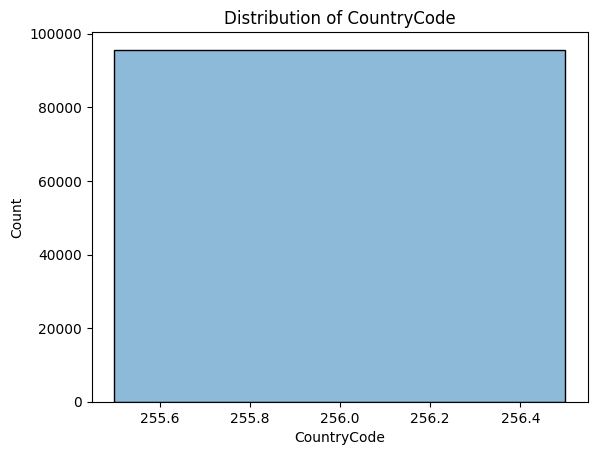

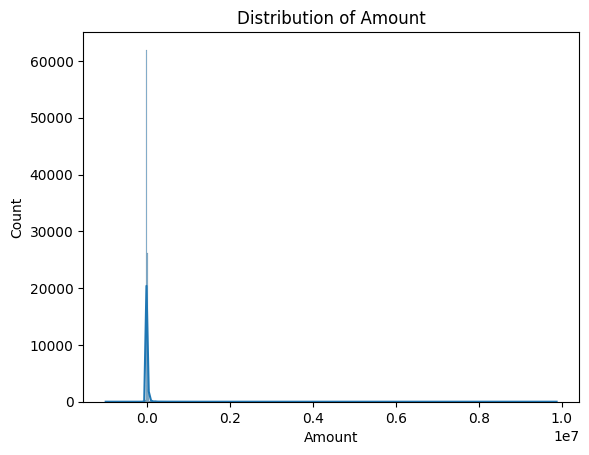

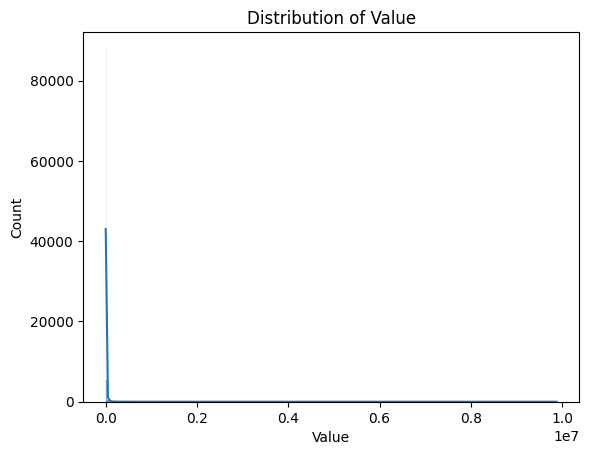

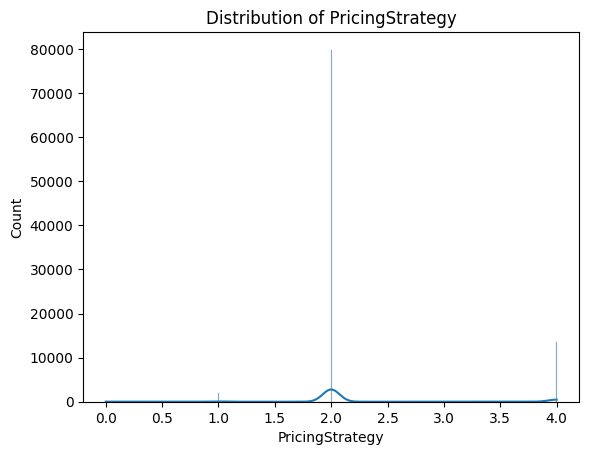

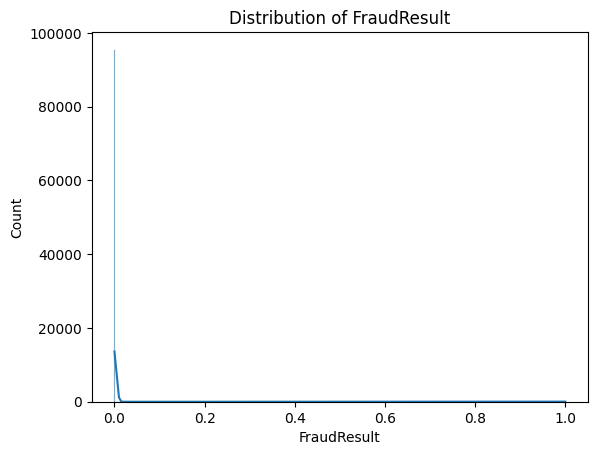

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## 4. Distribution of Categorical Features

We analyze categorical variables to understand class imbalance and frequency distribution.

C:\Users\redea\AppData\Local\Temp\ipykernel_25288\896947263.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


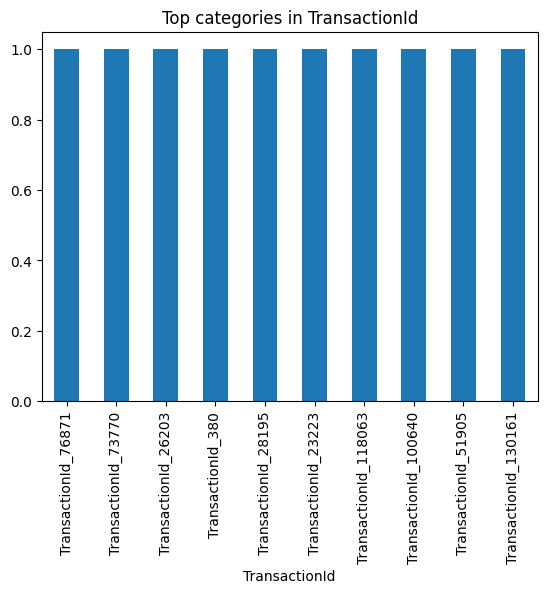

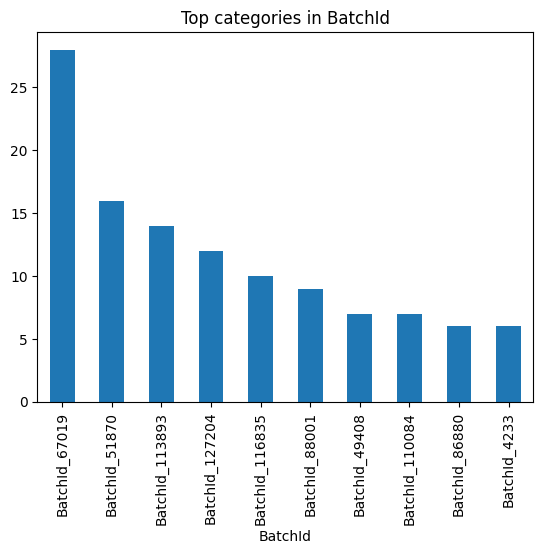

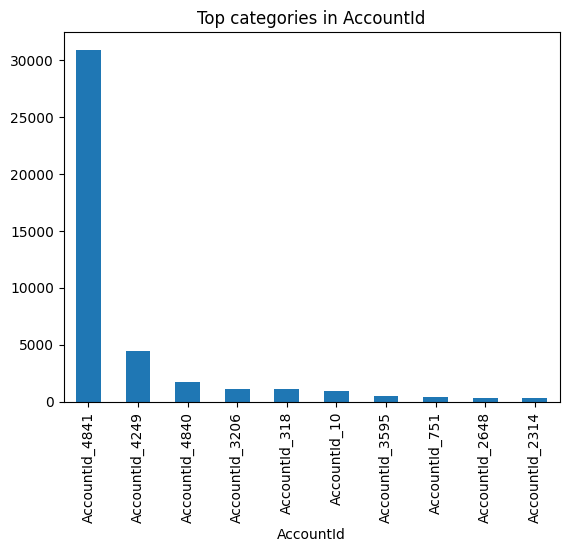

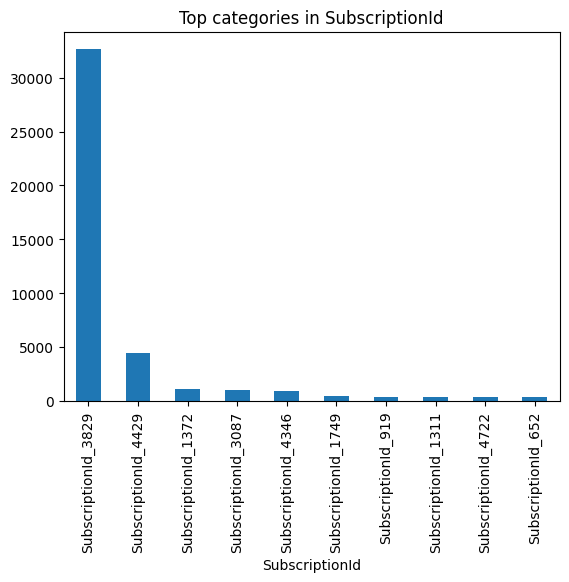

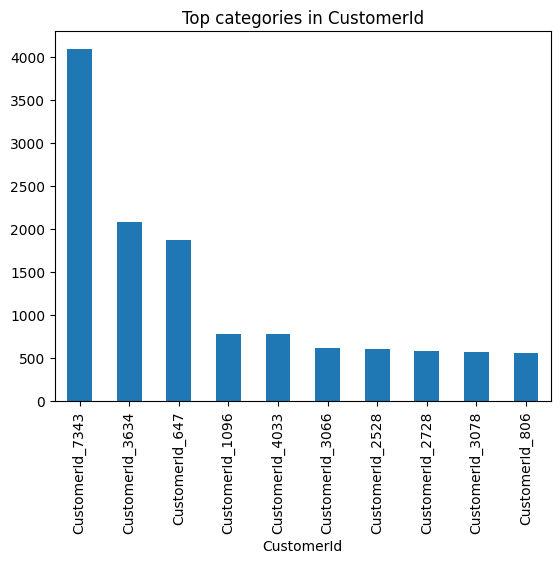

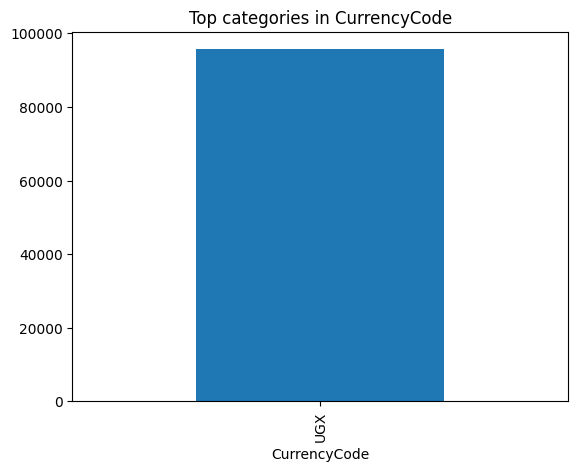

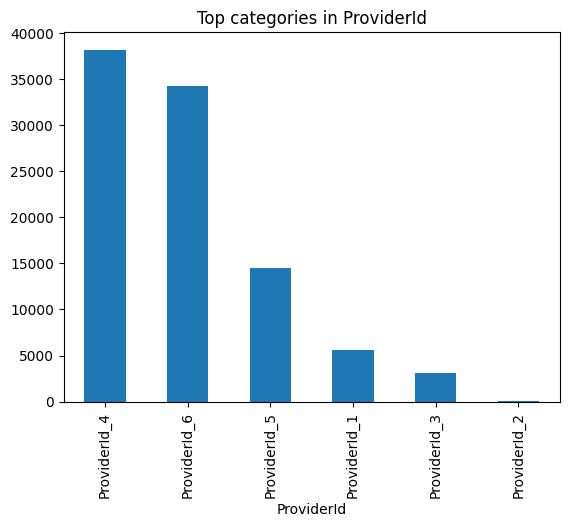

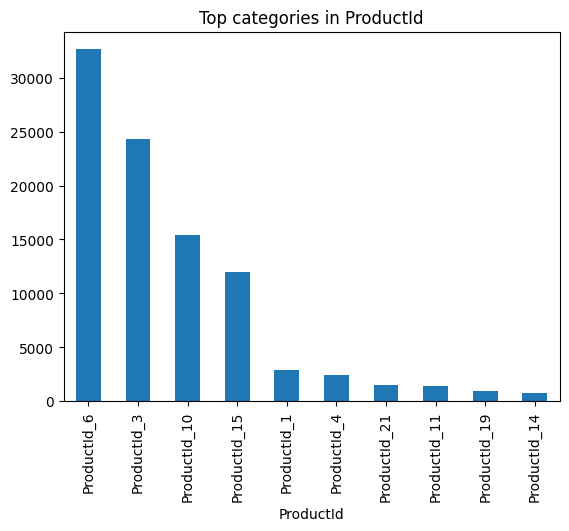

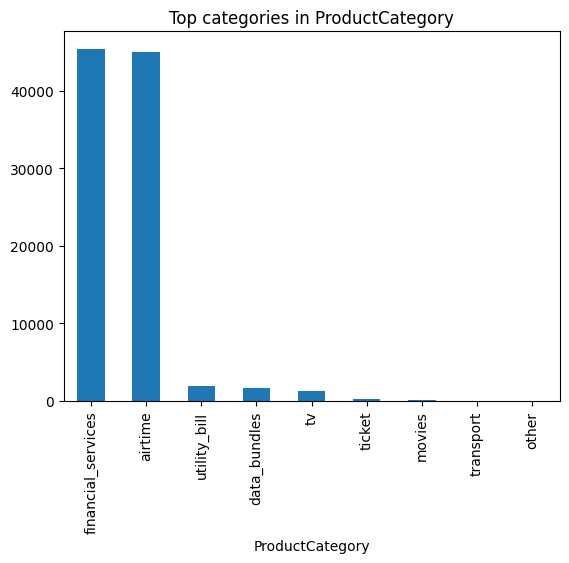

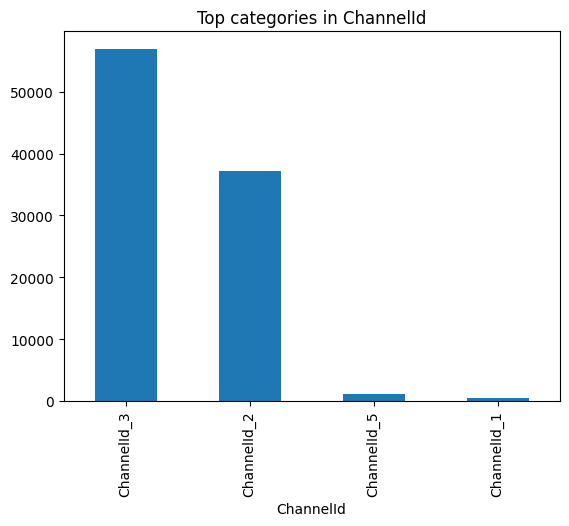

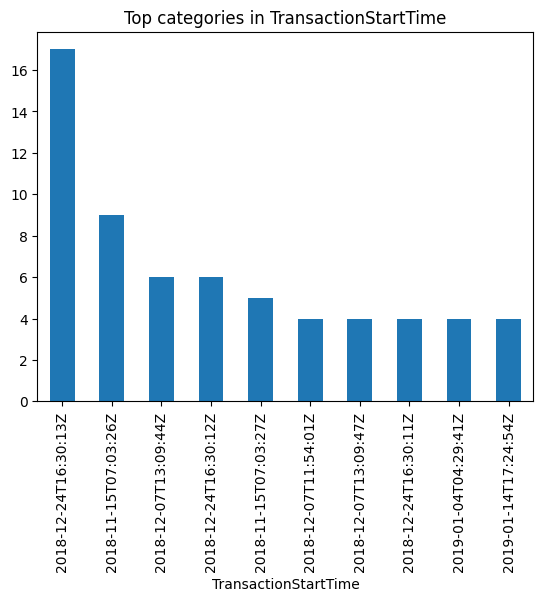

In [5]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"Top categories in {col}")
    plt.show()

## 5. Correlation Analysis

We examine correlations between numerical variables to identify relationships and multicollinearity.

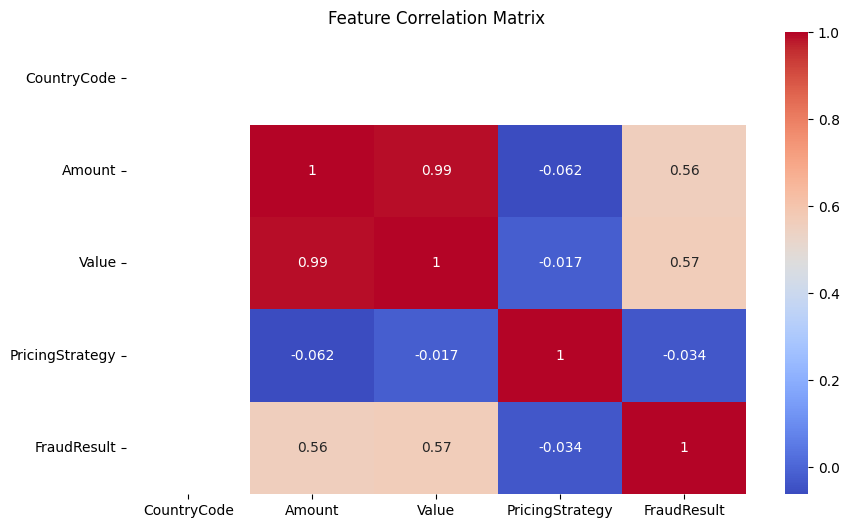

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

## 6. Missing Value Analysis

We identify missing values to determine data quality issues and potential imputation strategies.

In [7]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

## 7. Outlier Detection

We use boxplots to detect extreme values that may affect model performance.

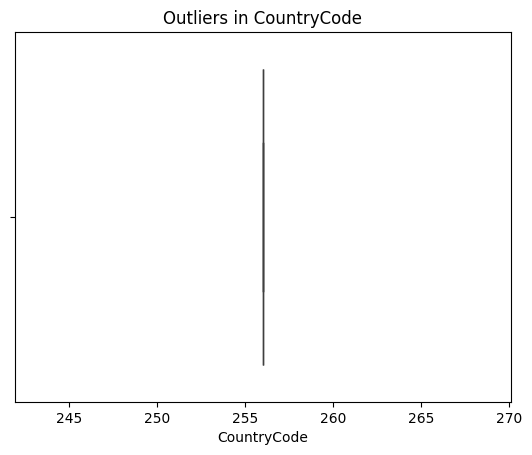

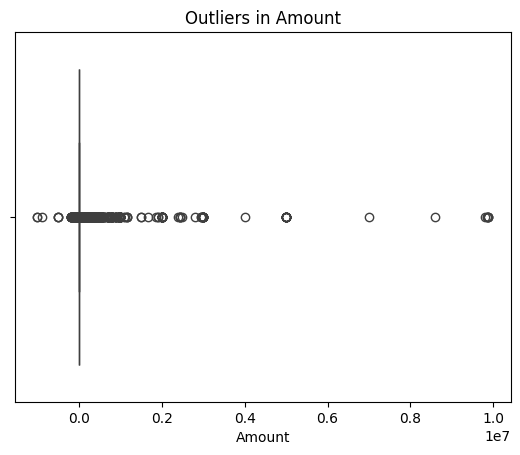

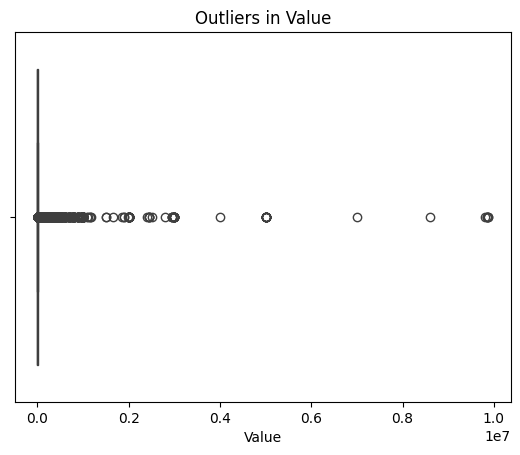

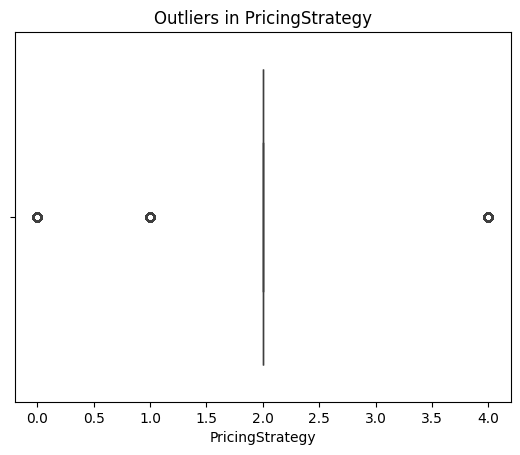

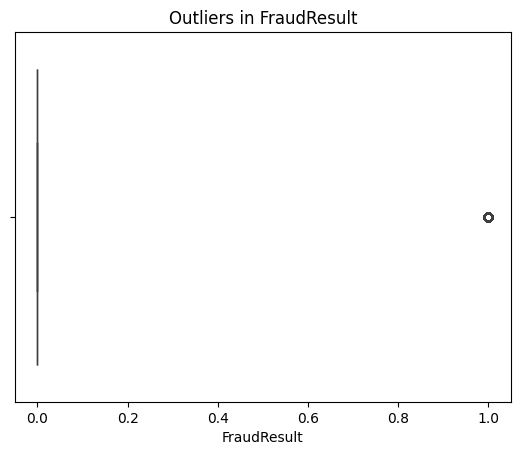

In [8]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

## 8. Key Insights

After exploratory analysis, the following key findings were observed:
1. Target Variable Imbalance
FraudResult is highly imbalanced, with most transactions having a value of 0.0 (non-fraud) and very few at 1.0 (fraud). This indicates a classic fraud detection imbalance problem, requiring techniques like oversampling, undersampling, or class weights during modeling.

2. PricingStrategy Distribution
PricingStrategy is concentrated around specific values (likely 0, 1, 2), with very low counts in between. This suggests it may be a categorical or ordinal feature rather than continuous. Some outliers are visible beyond the main clusters.

3. CountryCode Concentration
CountryCode is heavily concentrated around a narrow range (~255–257), meaning most transactions come from a small set of countries. This could lead to geographic bias in predictions.

4. Amount & Value Distributions
Amount and Value both show extreme skewness, with most values near zero and a long tail. The presence of 1e7 scale outliers in Value and Amount suggests these features need log transformation or capping.

5. Correlation Matrix
Amount and FraudResult show a moderate positive correlation (~0.57).

Value and FraudResult also show a moderate positive correlation (~0.56).

CountryCode and Amount are highly correlated (~0.99) — this is suspicious and may indicate a data artifact or redundant encoding. Further investigation is required.

PricingStrategy shows very weak correlation with fraud (~ -0.034 to -0.017).

6. Transaction Time
TransactionStartTime contains timestamps spanning late 2018 to early 2019. The extracted hour or day-of-week features may be useful for fraud pattern analysis.

7. Categorical Features
ChannelId has dominant categories: 3, 2, 5, 1.

ProductCategory is led by financial_services, airtime, utility_bill, data_bundles.

ProductId and ProviderId also have clear top categories, indicating potential for one-hot encoding or frequency-based grouping.

CurrencyCode appears to be almost a single value (likely USD or local currency), offering little predictive power.

CustomerId is high-cardinality, requiring aggregation (e.g., per-customer fraud rate or transaction count) rather than raw encoding.

8. Outliers
Significant outliers exist in Value, Amount, PricingStrategy, and CountryCode. These should be handled via clipping, winsorization, or transformation.

These insights will guide feature engineering and model development in the next stage.